# Part 1: Baseline Toxicity Classifier

This notebook fine-tunes `distilbert-base-uncased` on a stratified 100,000-row training subset of the Jigsaw dataset and evaluates it on a stratified 20,000-row holdout subset.

It prints Accuracy, macro F1, AUC-ROC, the confusion matrix, and threshold sweeps. It also saves the trained checkpoint to disk for later parts of the assignment.

In [1]:
# Uncomment if your environment is missing the required packages.
# !pip install -q transformers datasets accelerate scikit-learn seaborn pandas matplotlib torch

import os
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import Dataset
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, precision_recall_curve, average_precision_score
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding, Trainer, TrainingArguments, set_seed

os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["WANDB_DISABLED"] = "true"

SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

d:\Fast\semester_8\responsible_ai\assignment_02\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


In [2]:
DATA_PATH = os.path.join("dataset", "jigsaw-unintended-bias-train.csv")
USECOLS = ["comment_text", "toxic", "black", "white"]

df = pd.read_csv(
    DATA_PATH,
    usecols=USECOLS,
    dtype={
        "comment_text": "string",
        "toxic": "float32",
        "black": "float32",
        "white": "float32",
    },
)

df = df.dropna(subset=["comment_text", "toxic"]).copy()
df["label"] = (df["toxic"] >= 0.5).astype("int64")

print(f"Loaded rows: {len(df):,}")
print("Label distribution in full filtered dataset:")
print(df["label"].value_counts(normalize=True).sort_index())

train_df, eval_df = train_test_split(
    df,
    train_size=100_000,
    test_size=20_000,
    stratify=df["label"],
    random_state=SEED,
)

train_df = train_df.reset_index(drop=True)
eval_df = eval_df.reset_index(drop=True)

print(f"Training subset: {len(train_df):,}")
print(f"Evaluation subset: {len(eval_df):,}")
print("Training label distribution:")
print(train_df["label"].value_counts(normalize=True).sort_index())
print("Evaluation label distribution:")
print(eval_df["label"].value_counts(normalize=True).sort_index())

Loaded rows: 1,902,191
Label distribution in full filtered dataset:
label
0    0.920034
1    0.079966
Name: proportion, dtype: float64
Training subset: 100,000
Evaluation subset: 20,000
Training label distribution:
label
0    0.92003
1    0.07997
Name: proportion, dtype: float64
Evaluation label distribution:
label
0    0.92005
1    0.07995
Name: proportion, dtype: float64


In [3]:
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

train_hf = Dataset.from_pandas(train_df[["comment_text", "label"]], preserve_index=False)
eval_hf = Dataset.from_pandas(eval_df[["comment_text", "label"]], preserve_index=False)

def tokenize_function(batch):
    return tokenizer(batch["comment_text"], truncation=True, max_length=128)

train_hf = train_hf.map(tokenize_function, batched=True, remove_columns=["comment_text"])
eval_hf = eval_hf.map(tokenize_function, batched=True, remove_columns=["comment_text"])

train_hf = train_hf.rename_column("label", "labels")
eval_hf = eval_hf.rename_column("label", "labels")

print(train_hf)
print(eval_hf)

d:\Fast\semester_8\responsible_ai\assignment_02\venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\TECHMATCHED\.cache\huggingface\hub\models--distilbert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Map: 100%|██████████| 20000/20000 [00:02<00:00, 8980.95 examples/s]

Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 100000
})
Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 20000
})


In [7]:
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probabilities = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]
    predictions = (probabilities >= 0.5).astype(int)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1_macro": f1_score(labels, predictions, average="macro"),
        "auc_roc": roc_auc_score(labels, probabilities),
    }

training_args = TrainingArguments(
    output_dir="checkpoints/part1_distilbert_baseline",
    num_train_epochs=3,
    learning_rate=2e-5,
    weight_decay=0.01,
    per_device_train_batch_size=16 if torch.cuda.is_available() else 4,
    per_device_eval_batch_size=32 if torch.cuda.is_available() else 8,
    gradient_accumulation_steps=1 if torch.cuda.is_available() else 4,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    report_to="none",
    fp16=torch.cuda.is_available(),
    seed=SEED,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_hf,
    eval_dataset=eval_hf,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

train_result = trainer.train()
print(train_result)

checkpoint_dir = os.path.join("checkpoints", "part1_distilbert_baseline")
trainer.save_model(checkpoint_dir)
tokenizer.save_pretrained(checkpoint_dir)
print(f"Saved checkpoint to: {checkpoint_dir}")

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 14034.81it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Auc Roc
1,0.153266,0.142804,0.948100,0.797748,0.946611
2,0.116290,0.177315,0.947300,0.804939,0.944786
3,0.075950,0.227504,0.945550,0.804800,0.936778


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  5.72it/s]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=18750, training_loss=0.11927524490356445, metrics={'train_runtime': 458.1992, 'train_samples_per_second': 654.737, 'train_steps_per_second': 40.921, 'total_flos': 9844542409462080.0, 'train_loss': 0.11927524490356445, 'epoch': 3.0})


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  6.36it/s]

Saved checkpoint to: checkpoints\part1_distilbert_baseline


In [8]:
pred_output = trainer.predict(eval_hf)
eval_logits = pred_output.predictions
eval_labels = pred_output.label_ids
eval_probs = torch.softmax(torch.tensor(eval_logits), dim=-1).numpy()[:, 1]
eval_preds_05 = (eval_probs >= 0.5).astype(int)

accuracy = accuracy_score(eval_labels, eval_preds_05)
f1_macro = f1_score(eval_labels, eval_preds_05, average="macro")
auc_roc = roc_auc_score(eval_labels, eval_probs)
cm = confusion_matrix(eval_labels, eval_preds_05)

print(f"Accuracy:  {accuracy:.4f}")
print(f"F1 macro:  {f1_macro:.4f}")
print(f"AUC-ROC:   {auc_roc:.4f}")
print("Confusion matrix at threshold 0.5:")
print(cm)

print("Confusion matrix labels: [[TN, FP], [FN, TP]]")

Accuracy:  0.9474
F1 macro:  0.8051
AUC-ROC:   0.9448
Confusion matrix at threshold 0.5:
[[18017   384]
 [  669   930]]
Confusion matrix labels: [[TN, FP], [FN, TP]]


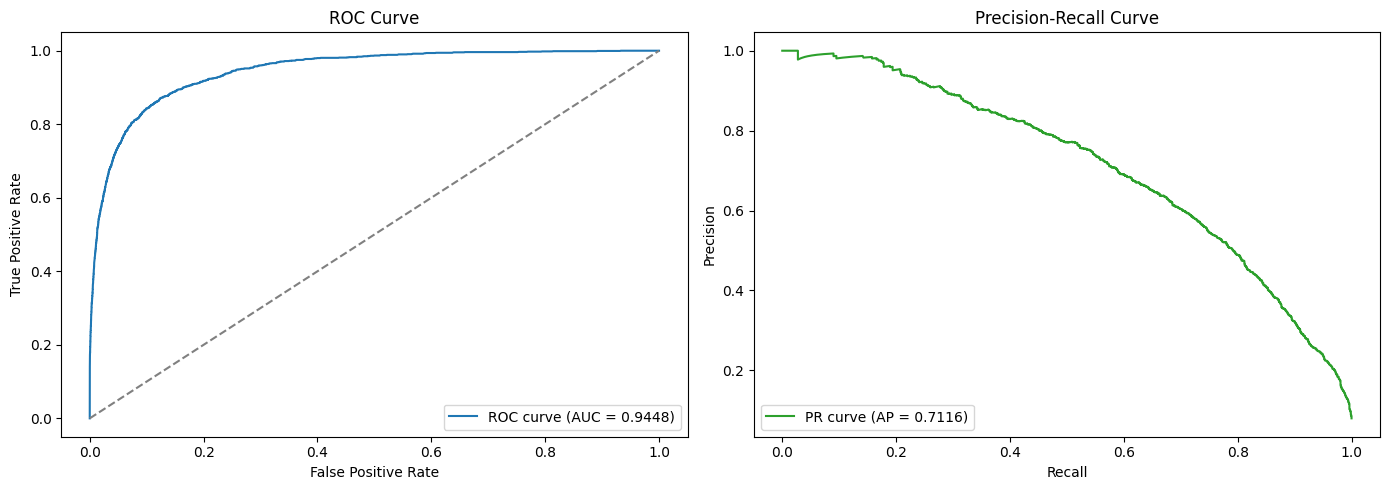

In [9]:
fpr, tpr, roc_thresholds = roc_curve(eval_labels, eval_probs)
precision, recall, pr_thresholds = precision_recall_curve(eval_labels, eval_probs)
average_precision = average_precision_score(eval_labels, eval_probs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(fpr, tpr, label=f"ROC curve (AUC = {auc_roc:.4f})", color="tab:blue")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend(loc="lower right")

axes[1].plot(recall, precision, label=f"PR curve (AP = {average_precision:.4f})", color="tab:green")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend(loc="lower left")

plt.tight_layout()
plt.show()

In [11]:
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
threshold_rows = []

for threshold in thresholds:
    threshold_predictions = (eval_probs >= threshold).astype(int)
    threshold_rows.append({
        "threshold": threshold,
        "accuracy": accuracy_score(eval_labels, threshold_predictions),
        "f1_macro": f1_score(eval_labels, threshold_predictions, average="macro"),
        "precision_toxic": (
            ((threshold_predictions == 1) & (eval_labels == 1)).sum() / max((threshold_predictions == 1).sum(), 1)
        ),
        "recall_toxic": (
            ((threshold_predictions == 1) & (eval_labels == 1)).sum() / max((eval_labels == 1).sum(), 1)
        ),
    })

threshold_df = pd.DataFrame(threshold_rows)
print(threshold_df.to_string(index=False))

best_threshold_row = threshold_df.sort_values(["f1_macro", "accuracy"], ascending=False).iloc[0]
chosen_threshold = float(best_threshold_row["threshold"])

print("Recommended operating threshold based on the sweep:")
print(f"threshold = {chosen_threshold:.1f}")
print("This threshold maximizes macro F1 on the evaluation subset among the tested values.")
if chosen_threshold < 0.5:
    print("Interpretation: the platform is prioritizing recall, catching more toxic content at the cost of more false positives.")
elif chosen_threshold > 0.5:
    print("Interpretation: the platform is prioritizing precision, reducing false positives at the cost of more missed toxicity.")
else:
    print("Interpretation: the platform is using the standard balanced cutoff.")

 threshold  accuracy  f1_macro  precision_toxic  recall_toxic
       0.3   0.94525  0.808719         0.667553      0.627892
       0.4   0.94640  0.806372         0.689160      0.600375
       0.5   0.94735  0.805062         0.707763      0.581614
       0.6   0.94810  0.803287         0.726027      0.563477
       0.7   0.94880  0.801144         0.746358      0.544715
Recommended operating threshold based on the sweep:
threshold = 0.3
This threshold maximizes macro F1 on the evaluation subset among the tested values.
Interpretation: the platform is prioritizing recall, catching more toxic content at the cost of more false positives.


## Threshold Justification

I will use the threshold selected by the sweep above, which is the value with the strongest macro F1 on the evaluation subset which is threshold = 0.3. In a moderation system, that choice reflects a balance between catching toxic comments and avoiding unnecessary false positives.

If the selected threshold is below 0.5, the platform is leaning toward recall and will catch more toxic content, but it will also flag more benign comments. If the selected threshold is above 0.5, the platform is leaning toward precision and will reduce false positives, but it will miss more genuinely toxic comments.

For the rest of the assignment, I will use the chosen threshold consistently when turning probabilities into hard labels.